<pre style="font-size: 15px; line-height: 1.2;">
---
course_code: 02BMSBI24365
course_title: AI and ML in Bioinformatics
unit: Unit 2 — Classical Machine Learning Algorithms
submodule: 2.1 Supervised Learning — Classification Models
scheduled_sessions: Sessions 09 & 10 (Day 09/10)
document_type: Practical Laboratory Notebook
ai_tier: Full AI (Learning Aid)
---


# 🧬 Hands-On: Classification Models in Clinical Diagnostics

In computational oncology and digital pathology, the most critical clinical decisions involve predicting **discrete diagnostic categories**:
* **Biopsy Cytopathology:** Classifying a Fine Needle Aspiration (FNA) breast tumor as **Benign ($0$)** or **Malignant ($1$)**.
* **Pharmacogenomics:** Predicting whether a patient will **Respond ($1$)** or **Relapse ($0$)** on targeted therapy.
* **Genomic Annotation:** Determining whether a sequence is a **Transcription Factor Binding Site ($1$)** or **Background DNA ($0$)**.

In this notebook, we follow the exact biological concepts from [2.1_classification_models_primer.md](2.1_classification_models_primer.md) to implement the 3 core classification algorithms in Python:

```text
                       CLASSIFICATION WORKFLOW
              (Predicting Discrete Biological Categories)
                                  │
           ┌──────────────────────┼──────────────────────┐
           ▼                      ▼                      ▼
 1. LOGISTIC REGRESSION     2. DECISION TREES      3. RANDOM FORESTS
• Linear boundary failure   • Clinical flowcharts  • 100-Tree Committee
• Sigmoid S-curve (0 to 1)  • IF/THEN rules        • Ensemble voting
• Clinical Odds Ratios      • export_text() SOP    • Biomarker discovery
• Protective vs Risk factors• plot_tree() diagram  • Gini feature importance
```

---

### 📋 Practical Agenda

1. **Logistic Regression (Probability Curves & Odds Ratios):**
   * Demonstrate why linear regression fails on binary diagnosis (negative and $>100\%$ probabilities).
   * Fit `LogisticRegression` to bend the prediction into a calibrated Sigmoid S-curve.
   * Calculate and plot clinical **Odds Ratios** ($\text{OR} = e^w$) to rank risk and protective biomarkers.
2. **Decision Trees (Clinical Flowcharts & Hard Rules):**
   * Train an interpretable `DecisionTreeClassifier(max_depth=2)` to learn clinical threshold cutoffs.
   * Extract plain-text IF/THEN Standard Operating Procedure rules using `export_text()`.
   * Render a graphical clinical decision flowchart using `plot_tree()`.
3. **Random Forests (Committee of Experts & Biomarker Discovery):**
   * Train an ensemble of 100 decision trees combining random patient samples (Bagging) and feature subspacing.
   * Extract and plot **Feature Importances** (Mean Decrease in Impurity) to discover candidate diagnostic biomarkers.


## Step 0: Setup & Imports

We import NumPy, Pandas, Matplotlib, and Scikit-learn's classification modules:
* `LogisticRegression`, `LinearRegression`
* `DecisionTreeClassifier`, `export_text`, `plot_tree`
* `RandomForestClassifier`


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Set fixed random seed for reproducible results
np.random.seed(42)

# Set clean visualization styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("Libraries imported successfully. Ready for clinical classification modeling.")


Libraries imported successfully. Ready for clinical classification modeling.


---

# 1. Logistic Regression: Biological Probabilities & S-Curves

## 1.1 Where Linear Regression Breaks on Binary Labels

From the theory primer, consider a pilot cohort of 8 breast biopsy patients. For each patient, we measure the **worst nuclear radius** ($\mu\text{m}$) and histopathological diagnosis (**$0 = \text{Benign}$**, **$1 = \text{Malignant}$**):

| Patient | Worst Nuclear Radius ($x$, $\mu\text{m}$) | Diagnosis ($y$) |
| :---: | :---: | :---: |
| P1 | 11.2 | $0$ (Benign) |
| P2 | 12.8 | $0$ (Benign) |
| P3 | 13.5 | $0$ (Benign) |
| P4 | 15.0 | $0$ (Benign) |
| P5 | 16.2 | $1$ (Malignant) |
| P6 | 18.5 | $1$ (Malignant) |
| P7 | 21.0 | $1$ (Malignant) |
| P8 | 24.3 | $1$ (Malignant) |

If we fit a straight line ($y = w \cdot x + b$) to binary labels, it extends infinitely to $\pm\infty$. What happens for patients with very small or very large cell nuclei?


In [ ]:
# 1. Create pilot cohort from theory primer
radii = np.array([11.2, 12.8, 13.5, 15.0, 16.2, 18.5, 21.0, 24.3]).reshape(-1, 1)
diagnosis = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# 2. Fit Linear Regression on binary labels
lin_model = LinearRegression()
lin_model.fit(radii, diagnosis)

# 3. Fit Logistic Regression on binary labels
log_model = LogisticRegression(random_state=42)
log_model.fit(radii, diagnosis)

# Evaluate extreme patient cases
p_small_lin = lin_model.predict([[8.0]])[0]
p_small_log = log_model.predict_proba([[8.0]])[0, 1]

p_large_lin = lin_model.predict([[28.0]])[0]
p_large_log = log_model.predict_proba([[28.0]])[0, 1]

print("=== Prediction on Extreme Patients ===")
print(f"Patient with Small Nuclei (Radius = 8.0 μm):")
print(f"  • Linear Regression:   y = {p_small_lin:+.2f} ({p_small_lin*100:+.1f}% probability) -> IMPOSSIBLE NEGATIVE PROBABILITY!")
print(f"  • Logistic Regression: P = {p_small_log:.4f} ({p_small_log*100:.2f}% probability) -> Calibrated Benign Confidence")
print(f"\nPatient with Giant Nuclei (Radius = 28.0 μm):")
print(f"  • Linear Regression:   y = {p_large_lin:+.2f} ({p_large_lin*100:+.1f}% probability) -> IMPOSSIBLE >100% PROBABILITY!")
print(f"  • Logistic Regression: P = {p_large_log:.4f} ({p_large_log*100:.2f}% probability) -> Calibrated Malignant Confidence")


=== Prediction on Extreme Patients ===
Patient with Small Nuclei (Radius = 8.0 μm):
  • Linear Regression:   y = -0.35 (-35.2% probability) -> IMPOSSIBLE NEGATIVE PROBABILITY!
  • Logistic Regression: P = 0.0004 (0.04% probability) -> Calibrated Benign Confidence

Patient with Giant Nuclei (Radius = 28.0 μm):
  • Linear Regression:   y = +1.64 (+163.8% probability) -> IMPOSSIBLE >100% PROBABILITY!
  • Logistic Regression: P = 1.0000 (100.00% probability) -> Calibrated Malignant Confidence


### Visualizing the Sigmoid Solution
We plot the linear regression fit alongside the logistic regression **Sigmoid S-curve**:
$$P(\text{Malignant} \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-(w \cdot x + b)}}$$


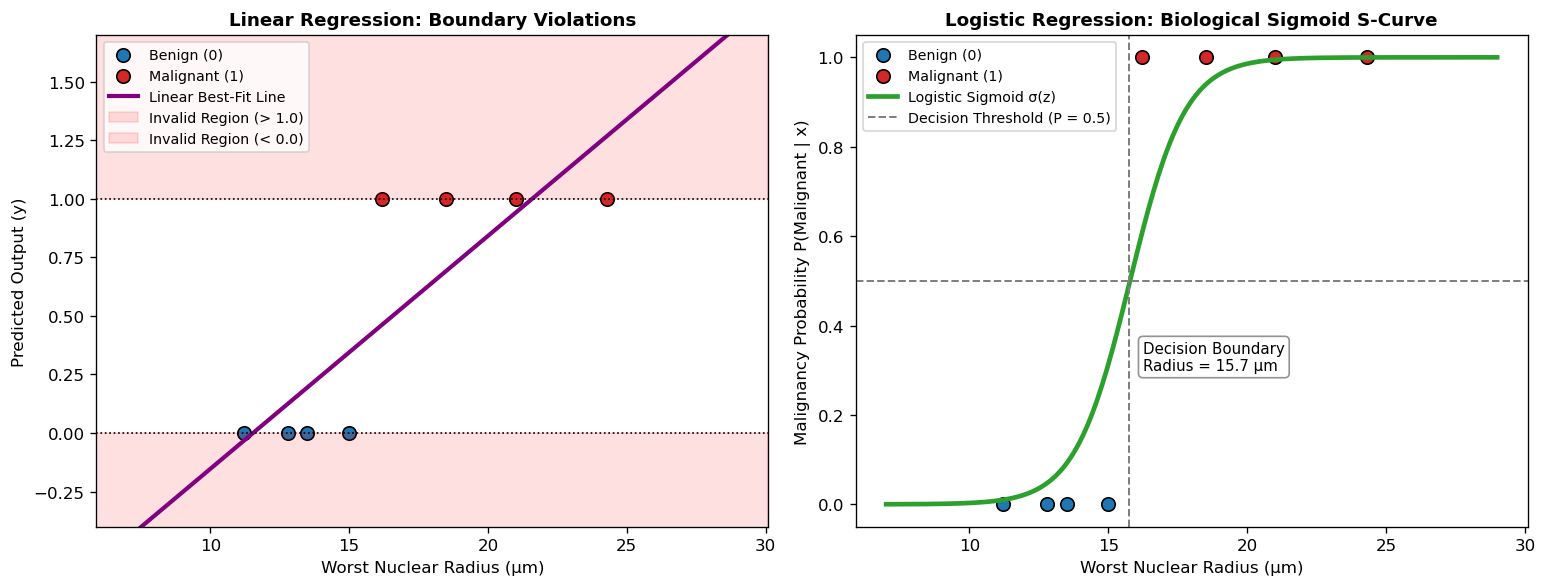

Key Takeaways:
  • Linear regression predicts impossible probabilities (<0% or >100%).
  • Logistic regression's Sigmoid naturally bounds all predictions strictly between 0.0 and 1.0!


In [ ]:
# Generate dense grid across radius values
radius_grid = np.linspace(7.0, 29.0, 250).reshape(-1, 1)
lin_preds = lin_model.predict(radius_grid)
log_probs = log_model.predict_proba(radius_grid)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# Panel 1: Linear Regression Breakdown
ax1.scatter(radii[diagnosis == 0], diagnosis[diagnosis == 0], color='#1f77b4', s=65, edgecolors='k', label='Benign (0)')
ax1.scatter(radii[diagnosis == 1], diagnosis[diagnosis == 1], color='#d62728', s=65, edgecolors='k', label='Malignant (1)')
ax1.plot(radius_grid, lin_preds, color='purple', lw=2.5, label='Linear Best-Fit Line')

# Highlight invalid probability regions (<0 and >1)
ax1.axhspan(1.0, 1.8, color='red', alpha=0.12, label='Invalid Region (> 1.0)')
ax1.axhspan(-0.5, 0.0, color='red', alpha=0.12, label='Invalid Region (< 0.0)')
ax1.axhline(0.0, color='k', linestyle=':', lw=1)
ax1.axhline(1.0, color='k', linestyle=':', lw=1)
ax1.set_title("Linear Regression: Boundary Violations", fontsize=11, fontweight='bold')
ax1.set_xlabel("Worst Nuclear Radius (μm)", fontsize=10)
ax1.set_ylabel("Predicted Output (y)", fontsize=10)
ax1.set_ylim(-0.4, 1.7)
ax1.legend(loc='upper left', fontsize=8.5)

# Panel 2: Logistic Regression Sigmoid Curve
ax2.scatter(radii[diagnosis == 0], diagnosis[diagnosis == 0], color='#1f77b4', s=65, edgecolors='k', label='Benign (0)')
ax2.scatter(radii[diagnosis == 1], diagnosis[diagnosis == 1], color='#d62728', s=65, edgecolors='k', label='Malignant (1)')
ax2.plot(radius_grid, log_probs, color='#2ca02c', lw=2.8, label='Logistic Sigmoid σ(z)')

# Clinical threshold at P = 0.5
ax2.axhline(0.5, color='gray', linestyle='--', lw=1.2, label='Decision Threshold (P = 0.5)')
boundary_idx = np.argmin(np.abs(log_probs - 0.5))
boundary_radius = radius_grid[boundary_idx][0]
ax2.axvline(boundary_radius, color='gray', linestyle='--', lw=1.2)
ax2.text(boundary_radius + 0.5, 0.3, f"Decision Boundary\nRadius = {boundary_radius:.1f} μm",
         fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))

ax2.set_title("Logistic Regression: Biological Sigmoid S-Curve", fontsize=11, fontweight='bold')
ax2.set_xlabel("Worst Nuclear Radius (μm)", fontsize=10)
ax2.set_ylabel("Malignancy Probability P(Malignant | x)", fontsize=10)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper left', fontsize=8.5)

plt.tight_layout()
plt.show()

print("Key Takeaways:")
print("  • Linear regression predicts impossible probabilities (<0% or >100%).")
print("  • Logistic regression's Sigmoid naturally bounds all predictions strictly between 0.0 and 1.0!")


## 1.2 Multi-Biomarker Model & Clinical Odds Ratios ($\text{OR} = e^w$)

In clinical oncology, we measure panels of cellular biomarkers. As covered in the theory primer, exponentiating the learned logistic regression weights yields **Odds Ratios** ($\text{OR} = e^w$):
* $\text{OR} > 1.0$: **Risk Factor** — each unit increase multiplies the odds of malignancy by $\text{OR}$.
* $\text{OR} < 1.0$: **Protective Factor** — higher values reduce the odds of malignancy.
* $\text{OR} = 1.0$: Neutral feature with no diagnostic association.

We simulate a clinical cohort of 60 patients with 4 key cellular measurements:
1. `worst_radius`: Nuclear enlargement (hallmark of cancer)
2. `worst_concave_points`: Nuclear border indentations / irregularities
3. `worst_texture`: Chromatin distribution heterogeneity
4. `intact_adhesion`: Normal cell-cell adhesion (protective against invasion)


In [ ]:
# Simulate 60 patient biopsies with 4 cellular measurements
n_patients = 60
worst_radius = np.random.uniform(10.0, 25.0, n_patients)
worst_concave = np.random.uniform(0.02, 0.25, n_patients)
worst_texture = np.random.uniform(12.0, 35.0, n_patients)
intact_adhesion = np.random.uniform(1.0, 10.0, n_patients)

# Generate biological log-odds (z)
# Positive terms = risk factors; Negative terms = protective factors
z_scores = (0.35 * (worst_radius - 17.0) +
            15.0 * (worst_concave - 0.12) +
            0.12 * (worst_texture - 22.0) -
            0.65 * (intact_adhesion - 5.0))

# Convert to malignancy probability via Sigmoid
malignancy_prob = 1.0 / (1.0 + np.exp(-z_scores))
patient_diagnosis = (malignancy_prob >= 0.5).astype(int)

# Put into a clean DataFrame
cohort_df = pd.DataFrame({
    'worst_radius': worst_radius,
    'worst_concave_points': worst_concave,
    'worst_texture': worst_texture,
    'intact_adhesion': intact_adhesion
})

print(f"Clinical cohort created: {n_patients} biopsies")
print(f"Class Balance: {np.sum(patient_diagnosis == 1)} Malignant / {np.sum(patient_diagnosis == 0)} Benign")
print("\nFirst 5 patient records:")
print(cohort_df.head(5).round(2))


Clinical cohort created: 60 biopsies
Class Balance: 30 Malignant / 30 Benign

First 5 patient records:
   worst_radius  worst_concave_points  worst_texture  intact_adhesion
0         15.62                  0.11          30.57             4.07
1         24.26                  0.08          32.61             2.02
2         20.98                  0.21          19.31             9.32
3         18.98                  0.10          14.53             8.90
4         12.34                  0.08          17.24             3.32


=== Learned Clinical Odds Ratios ===
           Biomarker  Weight (w)  Odds Ratio (exp(w))
        worst_radius    0.689392             1.992504
worst_concave_points    0.357844             1.430242
       worst_texture    0.263115             1.300976
     intact_adhesion   -1.520099             0.218690


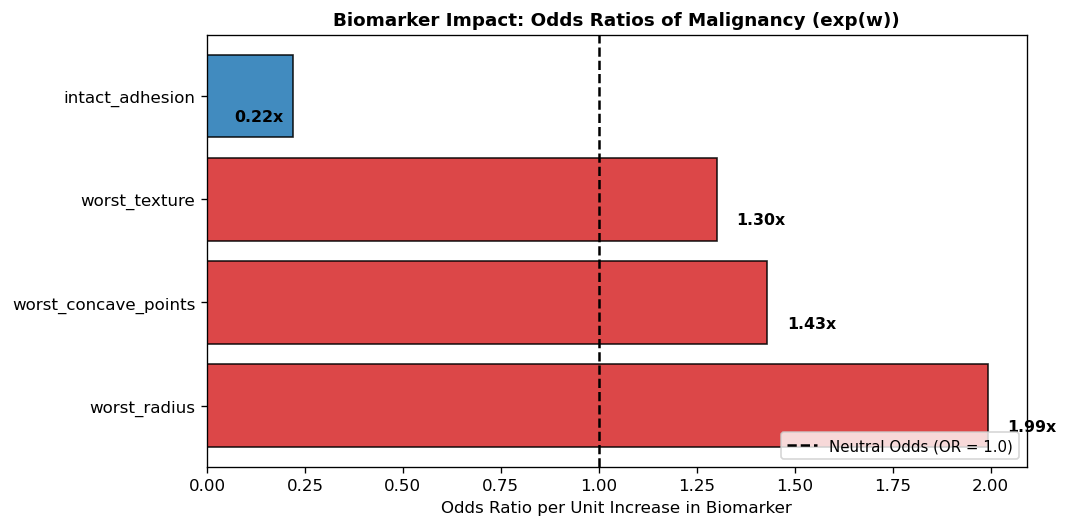

Clinical Takeaways:
  • Red bars (OR > 1.0): Risk factors (enlarged radius, irregular contour, higher texture increase malignancy odds).
  • Blue bars (OR < 1.0): Protective factors (intact cell adhesion reduces malignancy odds by over 70%).


In [ ]:
# Fit multi-biomarker Logistic Regression
multi_log_reg = LogisticRegression(random_state=42)
multi_log_reg.fit(cohort_df, patient_diagnosis)

# Extract learned weights and compute Odds Ratios (exp(w))
learned_weights = multi_log_reg.coef_[0]
odds_ratios = np.exp(learned_weights)

biomarker_summary = pd.DataFrame({
    'Biomarker': cohort_df.columns,
    'Weight (w)': learned_weights,
    'Odds Ratio (exp(w))': odds_ratios
}).sort_values(by='Odds Ratio (exp(w))', ascending=False)

print("=== Learned Clinical Odds Ratios ===")
print(biomarker_summary.to_string(index=False))

# Visualize Odds Ratios
fig, ax = plt.subplots(figsize=(9, 4.5))
bar_colors = ['#d62728' if or_val > 1.0 else '#1f77b4' for or_val in biomarker_summary['Odds Ratio (exp(w))']]

bars = ax.barh(biomarker_summary['Biomarker'], biomarker_summary['Odds Ratio (exp(w))'],
               color=bar_colors, edgecolor='k', alpha=0.85)
ax.axvline(1.0, color='black', linestyle='--', lw=1.5, label='Neutral Odds (OR = 1.0)')

for bar in bars:
    w = bar.get_width()
    offset = 0.05 if w >= 1.0 else -0.15
    ax.text(w + offset, bar.get_y() + bar.get_height()/4, f"{w:.2f}x",
            va='center', fontsize=9.5, fontweight='bold')

ax.set_title("Biomarker Impact: Odds Ratios of Malignancy (exp(w))", fontsize=11, fontweight='bold')
ax.set_xlabel("Odds Ratio per Unit Increase in Biomarker", fontsize=10)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print("Clinical Takeaways:")
print("  • Red bars (OR > 1.0): Risk factors (enlarged radius, irregular contour, higher texture increase malignancy odds).")
print("  • Blue bars (OR < 1.0): Protective factors (intact cell adhesion reduces malignancy odds by over 70%).")


---

# 2. Decision Trees: Clinical Flowcharts & Hard Rules

## Concept
While logistic regression computes smooth probability curves, pathology guidelines often operate on **hard binary cutoffs**:
* *IF* `intact_adhesion <= 6.3` *AND* `worst_texture > 12.6` $\longrightarrow$ **Malignant**

A **Decision Tree** algorithm automatically discovers this diagnostic flowchart by finding the sequence of binary questions that maximizes **Gini Impurity reduction**:
$$G = 1 - (p_{\text{benign}}^2 + p_{\text{malignant}}^2)$$
* $G = 0.0$: Completely pure diagnostic node ($100\%$ Benign or $100\%$ Malignant).
* $G = 0.5$: Maximal diagnostic uncertainty ($50/50$ split).

Unlike black-box models, decision trees are **interpretable**: clinicians can audit every single branching question.


In [ ]:
# Train a depth-constrained Decision Tree (max_depth=2) for clinical interpretability
tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model.fit(cohort_df, patient_diagnosis)

print("Decision Tree trained successfully with max_depth=2.")


Decision Tree trained successfully with max_depth=2.


### Step 2.1: Extract Text-Based SOP Rules (`export_text`)
Using Scikit-learn's `export_text()`, we extract the exact IF/THEN clinical standard operating procedure rules learned by the tree:


In [ ]:
# Extract text rules
clinical_rules = export_text(tree_model, feature_names=list(cohort_df.columns))
print("=== Extracted Clinical Protocol (IF/THEN Rules) ===")
print(clinical_rules)


=== Extracted Clinical Protocol (IF/THEN Rules) ===
|--- intact_adhesion <= 6.32
|   |--- worst_texture <= 12.61
|   |   |--- class: 0
|   |--- worst_texture >  12.61
|   |   |--- class: 1
|--- intact_adhesion >  6.32
|   |--- worst_radius <= 23.16
|   |   |--- class: 0
|   |--- worst_radius >  23.16
|   |   |--- class: 1



### Step 2.2: Render Visual Diagnostic Flowchart (`plot_tree`)
Using `plot_tree()`, we render a graphical diagnostic flowchart. Orange nodes indicate malignant-dominant diagnoses, blue nodes indicate benign-dominant diagnoses, and pure nodes have Gini $= 0.0$.


In [8]:
idex = cohort_df.loc[cohort_df['intact_adhesion'] > 6.32 ].index
patient_diagnosis[idex]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0])

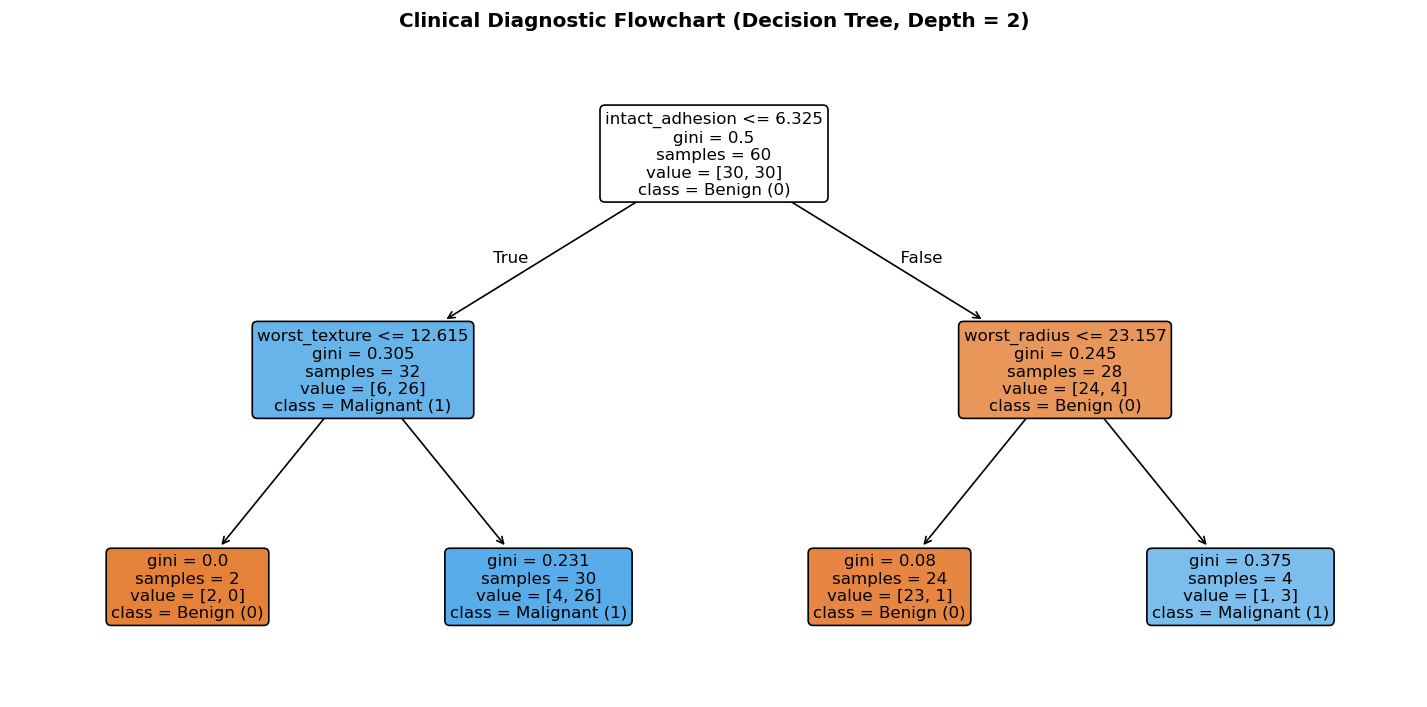

Takeaway:
  • The root question splits the patient cohort using the single most discriminative biomarker threshold.
  • Pathologists can read and verify each diagnostic path directly.


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_tree(
    tree_model,
    feature_names=list(cohort_df.columns),
    class_names=['Benign (0)', 'Malignant (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

ax.set_title("Clinical Diagnostic Flowchart (Decision Tree, Depth = 2)", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Takeaway:")
print("  • The root question splits the patient cohort using the single most discriminative biomarker threshold.")
print("  • Pathologists can read and verify each diagnostic path directly.")


### Understanding Gini Impurity in the Decision Tree

Gini impurity measures how often a randomly chosen element from a dataset would be incorrectly labeled if it were randomly labeled according to the distribution of class labels in that node. The formula to calculate Gini impurity is: 

$$ \text{Gini} = 1 - \sum_{i=1}^{C} p_i^2 $$

Where $C$ is the total number of classes (Benign and Malignant) and $p_i$ is the probability (fraction) of samples belonging to class $i$ in that node. 

Let's verify the mathematics behind our Decision Tree by computing the Gini impurities for two of its nodes programmatically:

In [10]:
print("=== Example 1: The Root Node (Top Box) ===")
# 1. Set the node distribution (30 Benign, 30 Malignant)
n_benign_1 = 30
n_malignant_1 = 30
total_samples_1 = n_benign_1 + n_malignant_1

# 2. Find the probabilities (p_i)
p_benign_1 = n_benign_1 / total_samples_1
p_malignant_1 = n_malignant_1 / total_samples_1

# 3. Square the probabilities and subtract from 1
gini_root = 1.0 - ((p_benign_1 ** 2) + (p_malignant_1 ** 2))

print(f"Total Samples: {total_samples_1}")
print(f"Probabilities: p(Benign) = {p_benign_1:.2f}, p(Malignant) = {p_malignant_1:.2f}")
print(f"Gini Impurity: 1 - ({p_benign_1:.2f}² + {p_malignant_1:.2f}²) = {gini_root:.3f}")
print("Meaning: An impurity of 0.500 is the highest possible uncertainty (a 50/50 split).\n")

print("=== Example 2: The Middle-Left Sub-node ===")
# 1. Set the node distribution (6 Benign, 26 Malignant)
n_benign_2 = 6
n_malignant_2 = 26
total_samples_2 = n_benign_2 + n_malignant_2

# 2. Find the probabilities (p_i)
p_benign_2 = n_benign_2 / total_samples_2
p_malignant_2 = n_malignant_2 / total_samples_2

# 3. Square the probabilities and subtract from 1
gini_node = 1.0 - ((p_benign_2 ** 2) + (p_malignant_2 ** 2))

print(f"Total Samples: {total_samples_2}")
print(f"Probabilities: p(Benign) = {p_benign_2:.4f}, p(Malignant) = {p_malignant_2:.4f}")
print(f"Gini Impurity: 1 - ({p_benign_2:.4f}² + {p_malignant_2:.4f}²) = {gini_node:.3f}")

=== Example 1: The Root Node (Top Box) ===
Total Samples: 60
Probabilities: p(Benign) = 0.50, p(Malignant) = 0.50
Gini Impurity: 1 - (0.50² + 0.50²) = 0.500
Meaning: An impurity of 0.500 is the highest possible uncertainty (a 50/50 split).

=== Example 2: The Middle-Left Sub-node ===
Total Samples: 32
Probabilities: p(Benign) = 0.1875, p(Malignant) = 0.8125
Gini Impurity: 1 - (0.1875² + 0.8125²) = 0.305


---

# 3. Random Forests: The Committee of Experts & Biomarker Discovery

## Concept
A single decision tree is transparent, but has a major drawback: **it easily overfits** idiosyncratic noise in the training cohort.

In clinical practice, challenging biopsies are reviewed by a **Multidisciplinary Tumor Board** — a committee of specialists who evaluate patient slides independently and cast collective votes.

A **Random Forest** implements this committee principle:
1. **Bagging (Bootstrap Aggregation):** Builds $100$ diverse trees, each trained on a random sample of patients drawn with replacement ($\approx 63\%$ unique patients per tree).
2. **Random Feature Subsets:** At every split, each tree inspects only a random subset of features ($\sqrt{p}$), preventing dominant markers from overshadowing subtler secondary signals.
3. **Consensus Voting:** Final diagnosis is established by majority vote, canceling out individual errors.
4. **Biomarker Discovery:** By averaging Gini Impurity drops across all 100 trees, the ensemble computes **Feature Importance** (Mean Decrease in Impurity), objectively ranking the most informative diagnostic biomarkers.


In [32]:
# Train a Random Forest ensemble of 100 decision trees
forest_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
forest_model.fit(cohort_df, patient_diagnosis)

# Extract Mean Decrease in Impurity (Feature Importance)
feature_importance_df = pd.DataFrame({
    'Biomarker': cohort_df.columns,
    'Importance': forest_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

print("=== Random Forest Biomarker Importance Rankings ===")
for _, row in feature_importance_df.sort_values(by='Importance', ascending=False).iterrows():
    print(f"  {row['Biomarker']:22s} | Importance = {row['Importance']:.4f}")


=== Random Forest Biomarker Importance Rankings ===
  intact_adhesion        | Importance = 0.4385
  worst_radius           | Importance = 0.2263
  worst_concave_points   | Importance = 0.1960
  worst_texture          | Importance = 0.1392


### Visualizing Candidate Biomarkers
We display a horizontal bar chart of the Gini Feature Importance rankings discovered by the 100-tree committee:


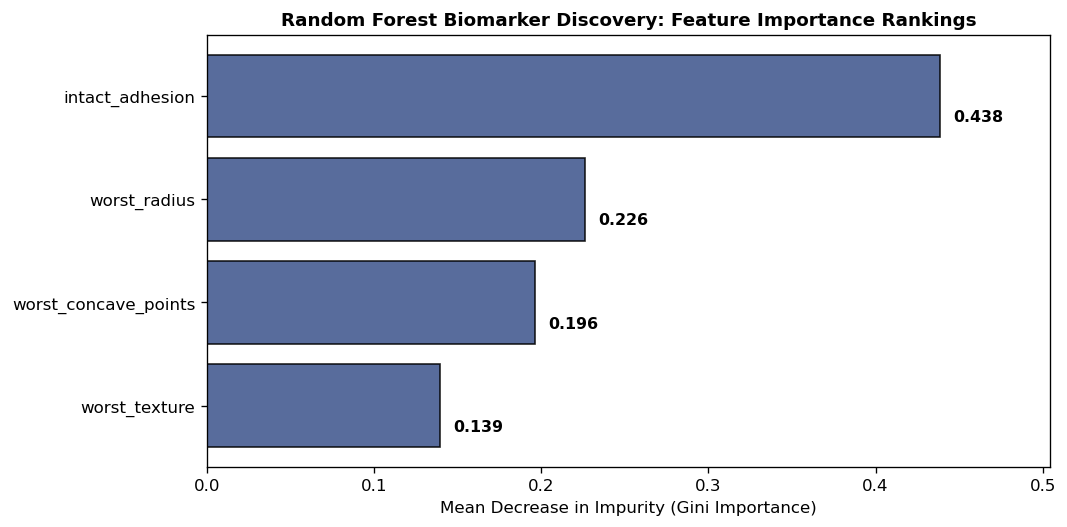

Summary of Algorithms:
  1. Logistic Regression: Smooth probabilities P in [0, 1] + Clinical Odds Ratios.
  2. Decision Tree: Transparent IF/THEN rules + clinical flowcharts.
  3. Random Forest: 100-tree committee voting + robust biomarker discovery rankings.


In [33]:
fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.barh(feature_importance_df['Biomarker'], feature_importance_df['Importance'],
               color='#3b528b', edgecolor='black', alpha=0.85)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.008, bar.get_y() + bar.get_height()/4, f"{w:.3f}",
            va='center', fontsize=9.5, fontweight='bold')

ax.set_title("Random Forest Biomarker Discovery: Feature Importance Rankings", fontsize=11, fontweight='bold')
ax.set_xlabel("Mean Decrease in Impurity (Gini Importance)", fontsize=10)
ax.set_xlim(0, max(feature_importance_df['Importance']) * 1.15)
plt.tight_layout()
plt.show()

print("Summary of Algorithms:")
print("  1. Logistic Regression: Smooth probabilities P in [0, 1] + Clinical Odds Ratios.")
print("  2. Decision Tree: Transparent IF/THEN rules + clinical flowcharts.")
print("  3. Random Forest: 100-tree committee voting + robust biomarker discovery rankings.")


---

## 📌 Summary & Takeaway Deliverable

### Recap
* **Logistic Regression:** Solves linear boundary failure using the Sigmoid curve $\sigma(z) = \frac{1}{1 + e^{-z}}$. Exponentiating learned weights yields clinical Odds Ratios ($\text{OR} = e^w$) for ranking risk vs. protective biomarkers.
* **Decision Trees:** Discovers hard binary cutoff rules to minimize Gini Impurity. Highly interpretable clinical SOPs can be audited via `export_text()` and `plot_tree()`.
* **Random Forests:** Combines 100 diverse decision trees via Bagging and random feature subspacing. Reduces prediction variance and ranks candidate biomarkers using Mean Decrease in Impurity.

### Takeaway Exercise (Submit via GitHub Issues)
1. Open the course GitHub repository in your browser.
2. Navigate to the **Issues** tab $\longrightarrow$ click **New Issue**.
3. Title your issue: `[Takeaway] <Student Name> - Classification Models`
4. Post:
   * A short code snippet applying either Logistic Regression, Decision Tree, or Random Forest.
   * Your model output (Odds Ratios, extracted IF/THEN rules, or Feature Importance ranking).
   * A 2-sentence clinical/biological interpretation of your results.